In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.metrics import r2_score

In [16]:
X, y = make_regression(n_samples=100, n_features=1, n_informative=2, n_targets=1, random_state=42, noise=20)

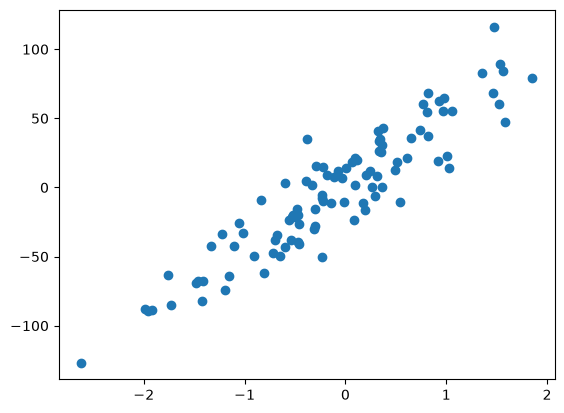

In [17]:
plt.scatter(X, y)

In [18]:
lr = LinearRegression()
lr.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[47.13]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.33
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[9.04]


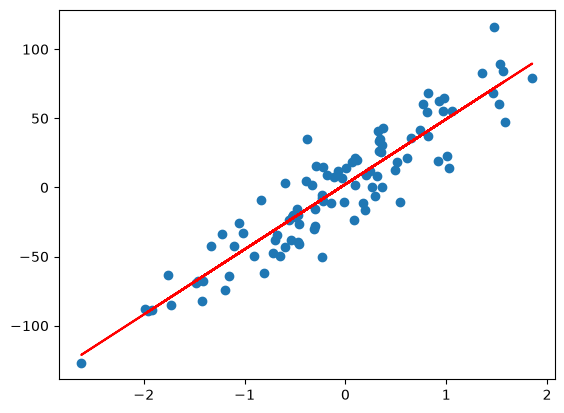

In [20]:
plt.scatter(X, y)
plt.plot(X, lr.predict(X), color='red')

In [24]:
# b = 
lr.intercept_

np.float64(2.330230641053945)

In [23]:
# m = 
lr.coef_

array([47.13323967])

In [47]:
r2_score(y, lr.predict(X))

0.853154207317982

# From scratch

In [37]:
class mygcd:
    def __init__(self, learning_rate, epochs):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.m = 0
        self.b = 1

    def fit(self, X, y):
        for _ in range(self.epochs):
            slope_b = -2 * np.sum(y - self.m * X.ravel() - self.b)
            slope_m = -2 * np.sum((y - self.m * X.ravel() - self.b)*X.ravel())
            self.b = self.b - self.learning_rate * slope_b
            self.m = self.m - self.learning_rate * slope_m
    def predict(self, X):
        return self.m * X.ravel() + self.b

In [38]:
gd = mygcd(0.001, 60)

In [39]:
gd.fit(X, y)

In [40]:
gd.m

np.float64(47.13171366881725)

In [41]:
gd.b

np.float64(2.3295301508515243)

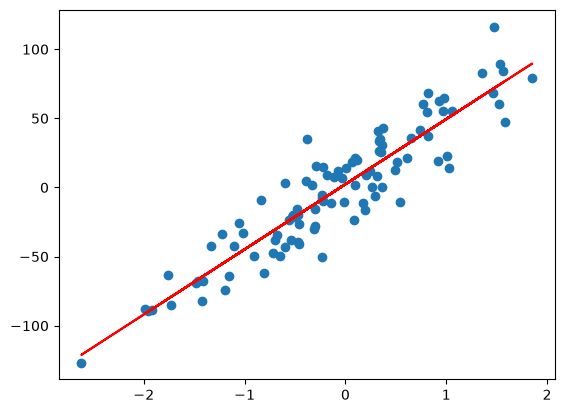

In [45]:
plt.scatter(X, y)
plt.plot(X, gd.predict(X), color='red')

In [48]:
r2_score(y, gd.predict(X))

0.8531542062855064